# Explore the data with Scanpy
**Authorship:** Adam Klie (last updated: 08/01/2023)<br>
***
**Description:** Notebook to explore the downloaded data with Seurat inlcuding checking the UMAP
***

In [52]:
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc

In [53]:
h5ad_file = "/cellar/users/aklie/data/igvf/topic_grn_links/h5ad/igvf_b01_LeftCortex/0.05/Microglia.h5ad"

In [54]:
adata = sc.read_h5ad(h5ad_file)
adata

/cellar/users/aklie/opt/miniconda3/envs/scverse-lite-py38/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 3251 × 3661
    obs: 'kallisto_cellID', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'sublibrary', 'Experiment', 'Kit', 'Tissue', 'Mouse_Tissue_ID', 'Genotype', 'Sex', 'Replicate', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Tissue_weight_mg', 'nCount_RNA', 'nFeature_RNA', 'doublet_scores', 'percent.mt', 'percent.ribo', 'G2M.Score', 'seurat_clusters', 'celltypes', 'subtypes', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [55]:
adata.obs.celltypes.value_counts()

Microglia    3251
Name: celltypes, dtype: int64

In [56]:
adata.X.todense()

matrix([[0., 0., 0., ..., 0., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.],
        ...,
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 1., 3.]], dtype=float32)

In [57]:
sc.pp.filter_cells(adata, min_genes=200)

In [58]:
adata.layers["raw_counts"] = adata.X.copy()

In [59]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [60]:
sc.pp.log1p(adata)

In [61]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

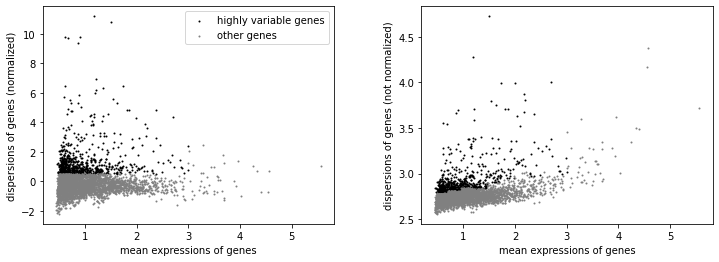

In [62]:
sc.pl.highly_variable_genes(adata)

In [63]:
adata = adata[:, adata.var.highly_variable]

In [64]:
sc.pp.scale(adata, max_value=10)

/cellar/users/aklie/opt/miniconda3/envs/scverse-lite-py38/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/cellar/users/aklie/opt/miniconda3/envs/scverse-lite-py38/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [65]:
sc.tl.pca(adata, svd_solver='arpack')

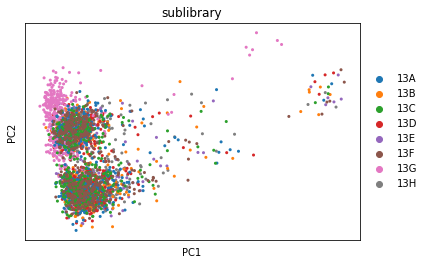

In [66]:
sc.pl.pca(adata, color='sublibrary')

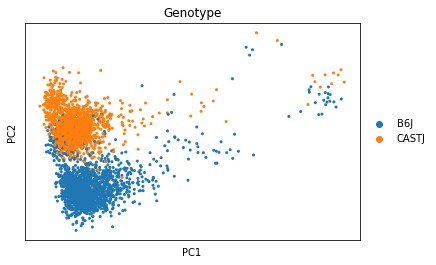

In [67]:
sc.pl.pca(adata, color='Genotype')

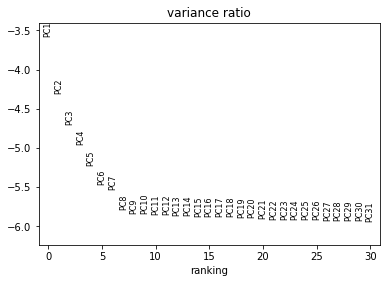

In [68]:
sc.pl.pca_variance_ratio(adata, log=True)

In [69]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

In [70]:
sc.tl.umap(adata)

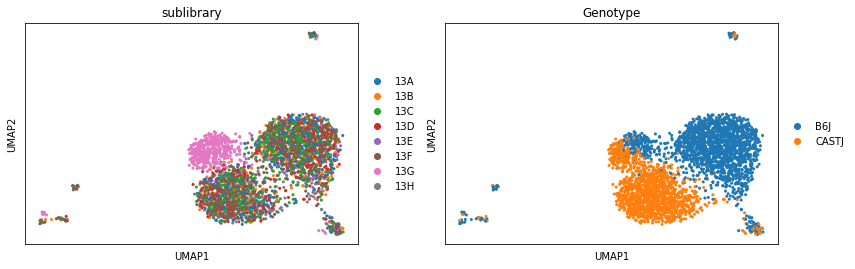

In [71]:
sc.pl.umap(adata, color=['sublibrary', 'Genotype'])